# Notebook 06a — Multi-Pathway NEB
## Hastelloy N | H₂ Dissociation Barrier Landscape

Enumerate all IS (H₂*) → FS (H*+H*) combinations, apply proximity filter, write NEB scripts and SLURM jobs, parse results, and plot barrier matrix.

**Requires:** Notebook 05 and Notebook 06 cell 3.3 to have completed.

**Project 2 additions:**
- Setup cell: loads `H2_site_coords.json` and `H_site_coords.json` for true labels
- Cell A: adds graph distance >= 2 check alongside H-H separation check
- Cell D: writes true labels to `neb_barrier.txt` and NEB script headers
- Cell E: parses and reports true labels in ranked barrier table

Change `SEED` to switch between seeds (7, 42, 12345).

### Cell 0 — Setup

All system paths, parameters, helpers, and previous results from NB05 and NB06.

Change `SEED` to switch between seeds (7, 42, 111, 1234, 12345).

In [1]:
import numpy as np
import os
import json
import subprocess
import shutil
import matplotlib.pyplot as plt
from ase.io import read
from collections import Counter
from itertools import combinations as iter_combinations
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# SEED — change this to switch between seeds
# ═══════════════════════════════════════════════════════════
SEED = 7

# ═══════════════════════════════════════════════════════════
# SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD        = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL_LAMMPS = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
MACE_MODEL_ASE    = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model'
MACE_MODEL        = MACE_MODEL_LAMMPS
KOKKOS_FLAGS      = ['-k', 'on', 'g', '1', '-sf', 'kk',
                     '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '06:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping ────────────────────────────────────────
ELEM_STR    = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'
E2T = {'Al':1, 'B':2, 'C':3, 'Cr':4, 'Fe':5, 'Mo':6, 'Ni':7, 'H':8}
MASSES = {
    1:(26.9815,'Al'), 2:(10.8110,'B'),  3:(12.0110,'C'),
    4:(51.9961,'Cr'), 5:(55.8450,'Fe'), 6:(95.9600,'Mo'),
    7:(58.6934,'Ni'), 8:( 1.0080,'H'),
}

# ── NEB parameters ───────────────────────────────────────────
N_REPLICAS   = 18
SPRING_CONST = 2.0
NEB_FTOL     = 0.05
N1_STEPS     = 5000
NEB_STEPS    = 10000

# ── Geometry constants ───────────────────────────────────────
Z_FREEZE_CUTOFF = 22.115
H_ATOM_HEIGHT   = 1.5
NN_CUTOFF       = 3.2

# ── Minimization settings ────────────────────────────────────
ETOL    = 0
FTOL    = 1e-6
MAXITER = 10000
MAXEVAL = 100000

# ── File paths ───────────────────────────────────────────────
SLAB_RELAXED = f'structures/notebook05-adsorption-energy/{SEED}/clean_slab_reminimized.lammps'

for d in [
    f'structures/notebook06-Neb-dissociation/{SEED}/multi',
    f'results/notebook06-Neb-dissociation/{SEED}/multi',
    f'lammps_scripts/notebook06-Neb-dissociation/{SEED}/multi',
    f'slurm_scripts/notebook06-Neb-dissociation/{SEED}/multi',
]:
    os.makedirs(d, exist_ok=True)

# ── Helper: parse energy log ─────────────────────────────────
def parse_energy_log(logfile):
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

# ═══════════════════════════════════════════════════════════
# READ PREVIOUS RESULTS FROM LOGS
# ═══════════════════════════════════════════════════════════
print(f'Reading results for SEED = {SEED}...')
print()

# E_clean_slab
res = parse_energy_log(f'results/notebook05-adsorption-energy/{SEED}/ads_clean_slab.log')
if res:
    E_CLEAN_SLAB = res['pe_final_eV']
    print(f'E_clean_slab  : {E_CLEAN_SLAB:.6f} eV')
else:
    raise FileNotFoundError(f'ads_clean_slab.log not found for seed {SEED}')

# E_H2_gas
res = parse_energy_log(f'results/notebook05-adsorption-energy/{SEED}/ads_h2_gas.log')
if res:
    E_H2_GAS = res['pe_final_eV']
    print(f'E_H2_gas      : {E_H2_GAS:.6f} eV')
else:
    raise FileNotFoundError(f'ads_h2_gas.log not found for seed {SEED}')

# Load site_coords.json
with open(f'results/notebook05-adsorption-energy/{SEED}/site_coords.json') as f:
    site_data = json.load(f)

z_surf       = site_data['z_surf']
z_H2         = site_data['z_H2']
min_dist     = site_data['min_dist']
H_ATOM_SITES = site_data['h_atom_sites']

# Use relaxed coords if available
if 'site_coords_relaxed' in site_data:
    SITE_COORDS = {k: tuple(v) for k, v in site_data['site_coords_relaxed'].items()}
    print('SITE_COORDS  : relaxed H positions (NB05 post-relaxation)')
else:
    SITE_COORDS = {k: tuple(v) for k, v in site_data['site_coords'].items()}
    print('SITE_COORDS  : nominal placement (NB05 pre-relaxation)')

RELAXED_LABELS = site_data.get('site_labels_relaxed', {})

print(f'z_surf       : {z_surf:.4f} A')
print(f'H_ATOM_SITES : {H_ATOM_SITES}')
print()

# Read NB06 single-H energies
h_energies = {}
h_eads     = {}

print('NB06 single-H adsorption energies:')
print(f'  {"Site":12s}  {"E_ads (eV)":>12s}  {"Status"}')
print('  ' + '-' * 40)

for site in H_ATOM_SITES:
    res = parse_energy_log(
        f'results/notebook06-Neb-dissociation/{SEED}/h_atom_{site}.log')
    if res and 'pe_final_eV' in res:
        h_energies[site] = res['pe_final_eV']
        h_eads[site]     = h_energies[site] - E_CLEAN_SLAB - 0.5 * E_H2_GAS
        print(f'  {site:12s}  {h_eads[site]:12.4f}  ok')
    else:
        print(f'  {site:12s}  {"N/A":>12s}  NOT FOUND')

if len(h_eads) == 0:
    raise RuntimeError(f'No NB06 single-H logs found for seed {SEED}. '                       f'Run NB06 cells 3.2-3.3 first.')

# Update SITE_COORDS with NB06 relaxed single-H positions
print()
print('Updating SITE_COORDS from NB06 relaxed single-H structures:')
for site in H_ATOM_SITES:
    rpath = f'structures/notebook06-Neb-dissociation/{SEED}/h_atom_{site}_relaxed.lammps'
    if not os.path.exists(rpath):
        continue
    slab = read(rpath, format='lammps-data', style='atomic')
    syms = np.array(slab.get_chemical_symbols())
    hpos = slab.get_positions()[syms == 'H']
    if len(hpos) == 1:
        old   = SITE_COORDS.get(site, (0, 0))
        SITE_COORDS[site] = (hpos[0][0], hpos[0][1])
        drift = np.sqrt((hpos[0][0]-old[0])**2 + (hpos[0][1]-old[1])**2)
        flag  = '  <- DRIFTED' if drift > 0.3 else ''
        print(f'  {site:12s}  ({hpos[0][0]:.4f}, {hpos[0][1]:.4f})  '              f'drift={drift:.4f} A{flag}')

print()
print('Setup complete.')

# ═══════════════════════════════════════════════════════════
# ADDITION 1 — Load true labels from Project 2
# ═══════════════════════════════════════════════════════════
import sys
sys.path.append('Project2_surface_labeling')
try:
    from surface_graph import build_surface_graph, get_site_neighbors
    import networkx as nx
    print('surface_graph module loaded')
except ImportError:
    print('WARNING: surface_graph.py not found — graph distance check disabled')
    build_surface_graph = None

# Load H2 true site labels (IS) from NB05 Phase 1 output
H2_SITE_COORDS_JSON = f'results/notebook05-adsorption-energy/{SEED}/H2_site_coords.json'
H2_TRUE_LABELS = {}
if os.path.exists(H2_SITE_COORDS_JSON):
    with open(H2_SITE_COORDS_JSON) as f:
        h2_data = json.load(f)
    H2_TRUE_LABELS = {k: v['true_label']
                      for k, v in h2_data.get('sites', {}).items()}
    print(f'H2 true labels loaded: {len(H2_TRUE_LABELS)} sites')
    for site, label in H2_TRUE_LABELS.items():
        print(f'  {site:12s} -> {label}')
else:
    print(f'WARNING: {H2_SITE_COORDS_JSON} not found')
    print('  Run NB05 cell 3.7c first to generate true H2 labels')

# Load H* true site labels (FS) from NB06 Phase 1 output
H_SITE_COORDS_JSON = f'results/notebook06-Neb-dissociation/{SEED}/H_site_coords.json'
H_TRUE_LABELS = {}
if os.path.exists(H_SITE_COORDS_JSON):
    with open(H_SITE_COORDS_JSON) as f:
        h_data = json.load(f)
    H_TRUE_LABELS = {k: v['true_label']
                     for k, v in h_data.get('sites', {}).items()}
    print(f'H* true labels loaded: {len(H_TRUE_LABELS)} sites')
    for site, label in H_TRUE_LABELS.items():
        print(f'  {site:12s} -> {label}')
else:
    print(f'WARNING: {H_SITE_COORDS_JSON} not found')
    print('  Run NB06 cell 3.3 replacement first to generate true H* labels')

# Build surface graph for graph distance calculation
SLAB_FOR_ACAT = f'structures/notebook05-adsorption-energy/{SEED}/clean_slab_reminimized.lammps'
G_surf = None
if build_surface_graph and os.path.exists(SLAB_FOR_ACAT):
    print('\nBuilding surface graph for graph distance...')
    G_surf, _, _, _ = build_surface_graph(SLAB_FOR_ACAT, seed=SEED)
    print(f'  Graph: {G_surf.number_of_nodes()} nodes, {G_surf.number_of_edges()} edges')
else:
    print('WARNING: Surface graph not available — graph distance check disabled')

def get_graph_distance(G, xy1, xy2):
    """Find nearest site nodes for two xy positions and return graph distance."""
    if G is None:
        return -1
    def nearest_site(xy):
        best, best_d = None, float('inf')
        for n, d in G.nodes(data=True):
            if d.get('node_type') != 'site': continue
            dist = ((d['x']-xy[0])**2 + (d['y']-xy[1])**2)**0.5
            if dist < best_d:
                best_d, best = dist, n
        return best
    n1 = nearest_site(xy1)
    n2 = nearest_site(xy2)
    if n1 is None or n2 is None:
        return -1
    site_g = nx.Graph()
    for u, v, d in G.edges(data=True):
        if d['edge_type'] == 'site-site':
            site_g.add_edge(u, v)
    try:
        return nx.shortest_path_length(site_g, n1, n2)
    except Exception:
        return -1

print('\nSetup complete.')


ASE version : 3.27.0
NumPy       : 2.4.3
Reading results for SEED = 7...

E_clean_slab  : -2390.925227 eV
E_H2_gas      : -6.790499 eV
SITE_COORDS  : relaxed H positions (NB05 post-relaxation)
z_surf       : 38.2290 A
H_ATOM_SITES : ['top_ni', 'top_mo', 'top_cr', 'top_fe', 'top_c', 'top_b', 'bridge', 'fcc_hollow', 'hcp_hollow']

NB06 single-H adsorption energies:
  Site            E_ads (eV)  Status
  ----------------------------------------
  top_ni             -0.6488  ok
  top_mo             -0.7956  ok
  top_cr             -0.4490  ok
  top_fe             -0.3202  ok
  top_c              -0.4490  ok
  top_b              -0.2363  ok
  bridge             -0.4259  ok
  fcc_hollow         -0.5062  ok
  hcp_hollow         -0.5062  ok

Updating SITE_COORDS from NB06 relaxed single-H structures:
  top_ni        (5.3689, 5.6969)  drift=3.2291 A  <- DRIFTED
  top_mo        (3.9556, 7.9741)  drift=1.3195 A  <- DRIFTED
  top_cr        (8.8959, 5.3132)  drift=1.9595 A  <- DRIFTED
  top_fe     

### Cell A — Enumerate all valid FS pairs

> Input: 'h_eads' dict and 'SITE_COORDS' (relaxed) from cell 3.3

> Logic:

     Take all pairs '(i, j)' from H_ATOM_SITES where i ≠ j

    - Keep pair if separation > 2.5 Å

    - Keep pair if both E_ads < 0

    - Sort pairs by combined stability '(E_ads[i] + E_ads[j])'

> Output: fs_pairs list of tuples '(site1, site2, sep, combined_eads)'

In [2]:
# ─────────────────────────────────────────────────────────────
# Cell A — Enumerate all valid FS pairs
# All H*+H* pairs with separation > 2.5 A and both E_ads < 0
# ─────────────────────────────────────────────────────────────
from itertools import combinations

FS_SEP_MIN = 2.5   # A — minimum H-H separation for dissociated pair
FS_SEP_MAX = 8.0   # A — maximum H-H separation (local dissociation)

fs_pairs = []

print('All valid FS pairs (H* + H*)')
print('=' * 65)
print(f'  {"Pair":30s}  {"Sep (A)":>8s}  {"E1+E2 (eV)":>12s}  {"Status"}')
print('  ' + '-' * 65)

sites_with_eads = [s for s in H_ATOM_SITES if s in h_eads and h_eads[s] < 0]

for s1, s2 in combinations(sites_with_eads, 2):
    x1, y1 = SITE_COORDS[s1]
    x2, y2 = SITE_COORDS[s2]
    sep = np.sqrt((x1-x2)**2 + (y1-y2)**2)
    combined = h_eads[s1] + h_eads[s2]

    if sep < FS_SEP_MIN:
        status = 'TOO CLOSE'
    elif sep > FS_SEP_MAX:
        status = 'TOO FAR'
    else:
        # Check graph distance — sites must not share a surface atom
        xy1 = SITE_COORDS[s1]
        xy2 = SITE_COORDS[s2]
        gdist = get_graph_distance(G_surf, xy1, xy2)
        if G_surf is not None and gdist >= 0 and gdist < 2:
            status = f'GRAPH DIST={gdist} (too close)'
        else:
            status = f'ok (graph_dist={gdist})'
            fs_pairs.append({
                'site1'        : s1,
                'site2'        : s2,
                'sep'          : sep,
                'graph_dist'   : gdist,
                'combined_eads': combined,
                'E_FS'         : h_energies[s1] + h_energies[s2] - E_CLEAN_SLAB,
                'label'        : f'{s1}+{s2}',
                'true_label1'  : H_TRUE_LABELS.get(s1, s1),
                'true_label2'  : H_TRUE_LABELS.get(s2, s2),
            })

    print(f'  {s1:15s} + {s2:15s}  {sep:8.4f}  {combined:12.4f}  {status}')

# Sort by combined stability
fs_pairs = sorted(fs_pairs, key=lambda x: x['combined_eads'])

print()
print(f'Valid FS pairs : {len(fs_pairs)}')
print()
print('Ranked by combined stability:')
for i, p in enumerate(fs_pairs, 1):
    tl1 = p.get('true_label1', p['site1'])
    tl2 = p.get('true_label2', p['site2'])
    print(f'  {i:2d}. {p["site1"]:12s} ({tl1}) + {p["site2"]:12s} ({tl2})  '
          f'sep={p["sep"]:.4f} A  graph_dist={p.get("graph_dist",-1)}  '
          f'E1+E2={p["combined_eads"]:.4f} eV')

All valid FS pairs (H* + H*)
  Pair                             Sep (A)    E1+E2 (eV)  Status
  -----------------------------------------------------------------
  top_ni          + top_mo             2.6802       -1.4444  GRAPH DIST=1 (too close)
  top_ni          + top_cr             3.5478       -1.0978  ok (graph_dist=2)
  top_ni          + top_fe             6.1935       -0.9690  ok (graph_dist=3)
  top_ni          + top_c              3.5478       -1.0978  ok (graph_dist=2)
  top_ni          + top_b              7.2069       -0.8851  ok (graph_dist=3)
  top_ni          + bridge             3.7811       -1.0748  ok (graph_dist=2)
  top_ni          + fcc_hollow         2.7578       -1.1550  GRAPH DIST=1 (too close)
  top_ni          + hcp_hollow         1.2838       -1.1550  TOO CLOSE
  top_mo          + top_cr             5.6114       -1.2445  ok (graph_dist=3)
  top_mo          + top_fe             8.8671       -1.1158  TOO FAR
  top_mo          + top_c              5.6114       

### Cell B — Enumerate all IS→FS combinations

Input: all H₂* sites from NB05, fs_pairs from Cell A
Logic:

For each NB05 site, read the relaxed structure to get H₂ center xy
For each FS pair, compute centroid xy of the two H* sites
Combine every IS with every FS pair → full combination matrix

Output: all_combinations list of dicts:

In [3]:
# ─────────────────────────────────────────────────────────────
# Cell B — Enumerate all IS→FS combinations
# Every NB05 H2* site × every valid FS pair
# IS sites and paths read from site_coords.json
# ─────────────────────────────────────────────────────────────
from ase.io import read as ase_read
import json

NB05_SITE_COORDS_JSON = f'results/notebook05-adsorption-energy/{SEED}/site_coords.json'

with open(NB05_SITE_COORDS_JSON) as f:
    nb05_data = json.load(f)

# Use relaxed H2 coords from NB05 if available, else nominal coords
if 'site_coords_relaxed' in nb05_data:
    nb05_coords = {k: tuple(v) for k, v in nb05_data['site_coords_relaxed'].items()}
    print('IS coords: using site_coords_relaxed from NB05')
else:
    nb05_coords = {k: tuple(v) for k, v in nb05_data['site_coords'].items()}
    print('IS coords: using nominal site_coords from NB05 (relaxed not found)')

NB05_SITES = nb05_data['h_atom_sites']
print(f'NB05 IS sites: {NB05_SITES}')
print()

print('Reading IS structures from NB05...')
is_structs  = {}
is_energies = {}

for site in NB05_SITES:
    struct_path = f'structures/notebook05-adsorption-energy/{SEED}/ads_{site}_relaxed.lammps'
    log_path    = f'results/notebook05-adsorption-energy/{SEED}/ads_{site}.log'

    if not os.path.exists(struct_path):
        print(f'  {site:12s}  relaxed structure not found — skipping')
        continue

    res = parse_energy_log(log_path)
    if res is None or 'pe_final_eV' not in res:
        print(f'  {site:12s}  log not found or no energy — skipping')
        continue

    slab = ase_read(struct_path, format='lammps-data', style='atomic')
    syms = np.array(slab.get_chemical_symbols())
    hpos = slab.get_positions()[syms == 'H']

    if len(hpos) == 2:
        # Use relaxed H2 centroid from site_coords_relaxed if available
        if site in nb05_coords:
            cx, cy = nb05_coords[site]
        else:
            cx, cy = hpos.mean(axis=0)[:2]
        is_structs[site]  = {'path': struct_path, 'xy': (cx, cy), 'hpos': hpos}
        is_energies[site] = res['pe_final_eV']
        print(f'  {site:12s}  H2 center=({cx:.4f}, {cy:.4f})  '              f'E={res["pe_final_eV"]:.6f} eV')
    else:
        print(f'  {site:12s}  unexpected H count: {len(hpos)} — skipping')

print()

# ── Build all IS→FS combinations ─────────────────────────────
all_combinations = []

for is_site, is_data in is_structs.items():
    ix, iy = is_data['xy']
    E_IS   = is_energies[is_site]

    for fp in fs_pairs:
        s1, s2   = fp['site1'], fp['site2']
        fx1, fy1 = SITE_COORDS[s1]
        fx2, fy2 = SITE_COORDS[s2]
        fcx      = (fx1 + fx2) / 2
        fcy      = (fy1 + fy2) / 2

        is_fs_dist = np.sqrt((ix - fcx)**2 + (iy - fcy)**2)

        # Approximate E_FS from sum of single-H energies minus one clean slab
        # (will be replaced by actual FS minimization energy during NEB run)
        E_FS   = h_energies[s1] + h_energies[s2] - E_CLEAN_SLAB
        dE     = E_FS - E_IS
        label  = f'{is_site}__{s1}+{s2}'

        all_combinations.append({
            'is_site'    : is_site,
            'fs_site1'   : s1,
            'fs_site2'   : s2,
            'is_xy'      : (ix, iy),
            'fs_centroid': (fcx, fcy),
            'is_fs_dist' : is_fs_dist,
            'E_IS'       : E_IS,
            'E_FS'       : E_FS,
            'delta_E'    : dE,
            'fs_sep'     : fp['sep'],
            'label'      : label,
        })

# Sort by delta_E most exothermic first
all_combinations = sorted(all_combinations, key=lambda x: x['delta_E'])

print(f'Total IS→FS combinations : {len(all_combinations)}')
print(f'  IS sites  : {len(is_structs)}')
print(f'  FS pairs  : {len(fs_pairs)}')
print()
print(f'  {"Label":45s}  {"IS-FS dist":>10s}  {"dE (eV)":>10s}')
print('  ' + '-' * 72)
for c in all_combinations:
    print(f'  {c["label"]:45s}  {c["is_fs_dist"]:10.4f}  {c["delta_E"]:10.4f}')


IS coords: using site_coords_relaxed from NB05
NB05 IS sites: ['top_ni', 'top_mo', 'top_cr', 'top_fe', 'top_c', 'top_b', 'bridge', 'fcc_hollow', 'hcp_hollow']

Reading IS structures from NB05...
  top_ni        H2 center=(4.3867, 2.6209)  E=-2397.877656 eV
  top_mo        H2 center=(4.0492, 6.6579)  E=-2398.104863 eV
  top_cr        H2 center=(10.0548, 3.7332)  E=-2397.862877 eV
  top_fe        H2 center=(10.3595, 0.2752)  E=-2397.895516 eV
  top_c         H2 center=(10.0761, 9.1138)  E=-2398.157466 eV
  top_b         H2 center=(6.4476, 10.7798)  E=-2398.201099 eV
  bridge        H2 center=(10.0692, 9.1222)  E=-2398.157466 eV
  fcc_hollow    H2 center=(5.1130, 2.6292)  E=-2398.195374 eV
  hcp_hollow    H2 center=(6.4053, 2.4248)  E=-2397.885022 eV

Total IS→FS combinations : 216
  IS sites  : 9
  FS pairs  : 24

  Label                                          IS-FS dist     dE (eV)
  ------------------------------------------------------------------------
  top_cr__top_mo+fcc_hollow  

### Cell C — Proximity filter

Input: all_combinations
Logic: keep only combinations where is_fs_dist < PROX_CUTOFF (suggest 5.0 Å as default, adjustable)
Output: filtered_combinations with summary table printed

In [4]:
# ─────────────────────────────────────────────────────────────
# Cell C — Proximity filter
# Keep only IS→FS pairs where IS H2 center is within PROX_CUTOFF
# of the FS pair centroid
# ─────────────────────────────────────────────────────────────
PROX_CUTOFF = 5.0   # A — adjustable

filtered_combinations = [c for c in all_combinations
                          if c['is_fs_dist'] < PROX_CUTOFF]

print(f'Proximity filter: IS-FS centroid distance < {PROX_CUTOFF} A')
print(f'  Before filter : {len(all_combinations)} combinations')
print(f'  After filter  : {len(filtered_combinations)} combinations')
print()
print(f'  {"#":>3s}  {"Label":45s}  {"IS-FS dist":>10s}  {"dE (eV)":>10s}  {"fs sep":>8s}')
print('  ' + '-' * 80)
for i, c in enumerate(filtered_combinations, 1):
    print(f'  {i:3d}  {c["label"]:45s}  {c["is_fs_dist"]:10.4f}  '
          f'{c["delta_E"]:10.4f}  {c["fs_sep"]:8.4f}')

print()
print(f'These {len(filtered_combinations)} combinations will have NEB scripts written.')
print('Adjust PROX_CUTOFF if too many or too few combinations remain.')

Proximity filter: IS-FS centroid distance < 5.0 A
  Before filter : 216 combinations
  After filter  : 124 combinations

    #  Label                                          IS-FS dist     dE (eV)    fs sep
  --------------------------------------------------------------------------------
    1  top_ni__top_mo+fcc_hollow                          2.8448     -1.1398    5.1720
    2  top_ni__top_mo+hcp_hollow                          3.9859     -1.1398    3.8568
    3  hcp_hollow__top_mo+fcc_hollow                      3.5513     -1.1324    5.1720
    4  hcp_hollow__top_mo+hcp_hollow                      4.2618     -1.1324    3.8568
    5  top_cr__top_mo+top_cr                              4.6520     -1.0974    5.6114
    6  top_cr__top_mo+top_c                               4.6520     -1.0974    5.6114
    7  top_ni__top_mo+top_cr                              4.5100     -1.0826    5.6114
    8  top_ni__top_mo+top_c                               4.5100     -1.0826    5.6114
    9  hcp_ho

### Cell D — Write all NEB scripts and SLURM jobs

For each combination in filtered_combinations:

Create directory structures/notebook06-Neb-dissociation/7/{label}/
Copy IS structure
Build FS structure from best1+best2 coordinates
Write run_ase_neb_{label}.py
Write SLURM script

In [5]:
# ─────────────────────────────────────────────────────────────
# Cell D — Write all NEB scripts and submit as SLURM array
# One NEB per IS→FS combination in filtered_combinations
# ─────────────────────────────────────────────────────────────
sc = SLURM_CONFIG
kk = ' '.join(KOKKOS_FLAGS)
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
               for p in sc['ld_paths'])
cwd = os.getcwd()

neb_jobs_written = []

for c in filtered_combinations:
    label    = c['label']
    is_site  = c['is_site']
    fs_site1 = c['fs_site1']
    fs_site2 = c['fs_site2']
    E_IS     = c['E_IS']
    true_is  = H2_TRUE_LABELS.get(is_site,  is_site)
    true_fs1 = H_TRUE_LABELS.get(fs_site1, fs_site1)
    true_fs2 = H_TRUE_LABELS.get(fs_site2, fs_site2)
    gdist    = c.get('graph_dist', -1)

    # ── Directories ───────────────────────────────────────────
    struct_dir = f'structures/notebook06-Neb-dissociation/{SEED}/multi/{label}'
    result_dir = f'results/notebook06-Neb-dissociation/{SEED}/multi/{label}'
    script_dir = f'lammps_scripts/notebook06-Neb-dissociation/{SEED}/multi/{label}'
    for d in [struct_dir, result_dir, script_dir]:
        os.makedirs(d, exist_ok=True)

    # ── IS structure — copy from NB05, strip Velocities ──────
    is_src  = f'structures/notebook05-adsorption-energy/{SEED}/ads_{is_site}_relaxed.lammps'
    is_dest = f'{struct_dir}/neb_initial.lammps'
    with open(is_src) as f:
        content = f.read()
    if 'Velocities' in content:
        content = content[:content.index('Velocities')].rstrip() + '\n'
    with open(is_dest, 'w') as f:
        f.write(content)

    # ── FS structure — place H atoms at fs_site1 + fs_site2 ──
    is_slab  = read(is_dest, format='lammps-data', style='atomic')
    is_pos   = is_slab.get_positions()
    is_syms  = np.array(is_slab.get_chemical_symbols())
    cell     = is_slab.cell.diagonal()
    z_surf_v = is_pos[is_syms != 'H', 2].max()
    z_fs     = z_surf_v + H_ATOM_HEIGHT

    x1, y1  = SITE_COORDS[fs_site1]
    x2, y2  = SITE_COORDS[fs_site2]
    h1_fs   = np.array([x1 % cell[0], y1 % cell[1], z_fs])
    h2_fs   = np.array([x2 % cell[0], y2 % cell[1], z_fs])

    metal_pos   = is_pos[is_syms != 'H']
    metal_syms  = is_syms[is_syms != 'H']
    fs_all_pos  = np.vstack([metal_pos, h1_fs, h2_fs])
    fs_all_syms = np.concatenate([metal_syms, ['H', 'H']])

    fs_raw_path = f'{struct_dir}/neb_final_raw.lammps'
    with open(fs_raw_path, 'w') as f:
        f.write(f'# NEB FS: 2H* at {fs_site1} + {fs_site2} — multi NEB\n\n')
        f.write(f'{len(fs_all_pos)} atoms\n8 atom types\n\n')
        f.write(f'0.0 {cell[0]:.10f} xlo xhi\n')
        f.write(f'0.0 {cell[1]:.10f} ylo yhi\n')
        f.write(f'0.0 {cell[2]:.10f} zlo zhi\n\n')
        f.write('Masses\n\n')
        for t, (m, el) in MASSES.items():
            f.write(f'{t}  {m}  # {el}\n')
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(fs_all_syms, fs_all_pos), 1):
            f.write(f'{i}  {E2T[sym]}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')

    # ── FS minimization LAMMPS script ─────────────────────────
    # Uses MACE_MODEL (= MACE_MODEL_LAMMPS) — same as all NB05/NB06 scripts
    fs_relaxed_path = f'{struct_dir}/neb_final_relaxed.lammps'
    fs_min_script   = f'{script_dir}/min_fs.lammps'
    fs_min_lines = [
        'units metal',
        'atom_style atomic',
        'newton on',
        'boundary p p f',
        '',
        f'read_data      {fs_raw_path}',
        '',
        f'pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}',
        f'pair_coeff     * * {ELEM_STR}',
        '',
        'neighbor       2.0 bin',
        'neigh_modify   every 1 delay 0 check yes',
        '',
        f'region         frozen_reg block INF INF INF INF EDGE {Z_FREEZE_CUTOFF}',
        'group          frozen_atoms region frozen_reg',
        'group          free_atoms subtract all frozen_atoms',
        'fix            freeze frozen_atoms setforce 0.0 0.0 0.0',
        '',
        'thermo         50',
        'thermo_style   custom step pe fmax',
        '',
        f'minimize       {ETOL} {FTOL} {MAXITER} {MAXEVAL}',
        '',
        'variable pe_final equal pe',
        'variable fmax_f   equal fmax',
        '',
        'print "ENERGY_RESULTS_START"',
        f'print "  job_name         : fs_min_{label}"',
        'print "  pe_final_eV      : ${pe_final}"',
        'print "  fmax_eV_per_Ang  : ${fmax_f}"',
        'print "ENERGY_RESULTS_END"',
        '',
        f'write_data {fs_relaxed_path}',
    ]
    with open(fs_min_script, 'w') as f:
        f.write('\n'.join(fs_min_lines) + '\n')

    # ── ASE NEB script ────────────────────────────────────────
    # Uses MACE_MODEL_ASE — same as NB06 run_ase_neb06.py pattern
    neb_script_path = f'{script_dir}/run_neb.py'
    neb_lines = [
        '#!/usr/bin/env python3',
        f'# Multi-pathway NEB: {label}',
        f'label = "{label}"',
        f'# IS: H2* at {is_site}  (true label: {true_is})',
        f'# FS: 2H* at {fs_site1} + {fs_site2}',
        f'# FS true labels: {true_fs1} + {true_fs2}',
        f'# Graph distance between FS sites: {gdist}',
        '',
        'import os, sys, numpy as np, torch',
        'from ase.io import read',
        'from ase.mep import NEB',
        'from ase.optimize import MDMin',
        'from ase.calculators.singlepoint import SinglePointCalculator',
        'from mace.calculators import MACECalculator',
        '',
        '# Strip CUDA stubs from LD path — causes segfault on some nodes',
        '_ld = os.environ.get("LD_LIBRARY_PATH", "")',
        'os.environ["LD_LIBRARY_PATH"] = ":".join(',
        '    p for p in _ld.split(":") if "stubs" not in p)',
        '',
        f'MACE_MODEL      = "{MACE_MODEL_ASE}"',
        f'NEB_IS_FILE     = "{is_dest}"',
        f'FS_RELAXED_DATA = "{fs_relaxed_path}"',
        f'Z_FREEZE_CUTOFF = {Z_FREEZE_CUTOFF}',
        f'E_IS            = {E_IS}',
        f'N_IMAGES        = {N_REPLICAS}',
        f'NEB_FMAX        = {NEB_FTOL}',
        f'N1_STEPS        = {N1_STEPS}',
        f'NEB_STEPS       = {NEB_STEPS}',
        f'SPRING_CONST    = {SPRING_CONST}',
        'N1_FMAX         = NEB_FMAX * 3',
        '',
        'device = "cuda" if torch.cuda.is_available() else "cpu"',
        'print(f"Device: {device}")',
        'sys.stdout.flush()',
        '',
        'class MACEFrozenCalc(MACECalculator):',
        '    def get_forces(self, atoms=None):',
        '        forces = super().get_forces(atoms).copy()',
        '        a = self.atoms if atoms is None else atoms',
        '        forces[a.get_positions()[:, 2] < Z_FREEZE_CUTOFF] = 0.0',
        '        return forces',
        '',
        'def make_calc():',
        '    """Fresh calculator instance for each intermediate image."""',
        '    return MACEFrozenCalc(',
        '        model_paths=MACE_MODEL,',
        '        device=device,',
        '        default_dtype="float64",',
        '    )',
        '',
        '# Read E_FS from FS minimization log',
        f'fs_log = "{result_dir}/fs_min.log"',
        'E_FS = None',
        'with open(fs_log) as f:',
        '    for line in f:',
        '        if "pe_final_eV" in line and ":" in line:',
        '            try: E_FS = float(line.split(":")[1].strip())',
        '            except: pass',
        'if E_FS is None:',
        '    raise FileNotFoundError(f"FS log not found or no energy: {fs_log}")',
        'print(f"E_IS = {E_IS:.6f} eV")',
        'print(f"E_FS = {E_FS:.6f} eV")',
        'print(f"dE   = {E_FS - E_IS:.4f} eV")',
        'sys.stdout.flush()',
        '',
        'print("Loading IS and FS...")',
        'is_raw = read(NEB_IS_FILE,     format="lammps-data", style="atomic")',
        'fs_raw = read(FS_RELAXED_DATA, format="lammps-data", style="atomic")',
        '',
        'is_end = is_raw.copy()',
        'is_end.calc = SinglePointCalculator(is_end)',
        'is_end.calc.results = {"energy": E_IS, "forces": np.zeros((len(is_end), 3))}',
        '',
        'fs_end = fs_raw.copy()',
        'fs_end.calc = SinglePointCalculator(fs_end)',
        'fs_end.calc.results = {"energy": E_FS, "forces": np.zeros((len(fs_end), 3))}',
        '',
        'images = [is_end]',
        'for _ in range(N_IMAGES):',
        '    img = is_raw.copy()',
        '    img.calc = make_calc()',
        '    images.append(img)',
        'images.append(fs_end)',
        '',
        'print(f"Images: {len(images)} total ({N_IMAGES} intermediate + IS + FS)")',
        'sys.stdout.flush()',
        '',
        'neb = NEB(images, climb=False, k=SPRING_CONST, method="aseneb")',
        'neb.interpolate(method="idpp")',
        '',
        'print("IDPP done. H-H distances:")',
        'for i, img in enumerate(images):',
        '    lbl = "IS" if i==0 else ("FS" if i==len(images)-1 else f"img_{i}")',
        '    p = img.get_positions()',
        '    s = np.array(img.get_chemical_symbols())',
        '    h = p[s=="H"]',
        '    hh = np.linalg.norm(h[0]-h[1]) if len(h)==2 else 0.0',
        '    print(f"  {lbl:6s}: H-H = {hh:.4f} A")',
        'sys.stdout.flush()',
        '',
        f'print(f"\\nPhase 1: regular NEB ({N1_STEPS} steps)")',
        'sys.stdout.flush()',
        f'opt1 = MDMin(neb, logfile="{result_dir}/neb_phase1.log", dt=0.05)',
        'opt1.run(fmax=N1_FMAX, steps=N1_STEPS)',
        'print(f"Phase 1 done: {opt1.nsteps} steps")',
        'sys.stdout.flush()',
        '',
        'for img in images[1:-1]:',
        '    img.set_momenta(np.zeros_like(img.get_momenta()))',
        '',
        'neb.climb = True',
        f'print(f"\\nPhase 2: CINEB ({NEB_STEPS} steps, fmax={NEB_FTOL:.3f} eV/A)")',
        'sys.stdout.flush()',
        f'opt2 = MDMin(neb, logfile="{result_dir}/neb_phase2.log", dt=0.02)',
        'try:',
        '    opt2.run(fmax=NEB_FMAX, steps=NEB_STEPS)',
        'except Exception as e:',
        '    print(f"WARNING: phase 2 raised: {e}")',
        '    sys.stdout.flush()',
        'print(f"Phase 2 done: {opt2.nsteps} steps")',
        'sys.stdout.flush()',
        '',
        f'with open("{result_dir}/neb_phase2.log") as _f:',
        '    _last = [l for l in _f if l.strip()][-1]',
        'fmax_final = float(_last.split()[-1])',
        'converged  = fmax_final < NEB_FMAX',
        'print(f"fmax: {fmax_final:.4f} eV/A  Converged: {converged}")',
        'sys.stdout.flush()',
        '',
        'energies = []',
        'for img in images:',
        '    try:    energies.append(img.get_potential_energy())',
        '    except: energies.append(None)',
        '',
        'valid  = [e for e in energies if e is not None]',
        'E_a    = max(valid) - E_IS',
        'dE_rxn = E_FS - E_IS',
        '',
        'print(f"\\nNEB Results: {label}")',
        'print(f"  E_IS    : {E_IS:.6f} eV")',
        'print(f"  E_FS    : {E_FS:.6f} eV")',
        'print(f"  E_a     : {E_a:.4f} eV")',
        'print(f"  delta_E : {dE_rxn:.4f} eV")',
        'print(f"  fmax    : {fmax_final:.4f} eV/A")',
        'print(f"  Converged: {converged}")',
        'sys.stdout.flush()',
        '',
        f'barrier_file = "{result_dir}/neb_barrier.txt"',
        f'path_file    = "{result_dir}/neb_path.dat"',
        '',
        'with open(barrier_file, "w", encoding="utf-8") as f:',
        f'    f.write("IS : H2* at {is_site}\\n")',
        f'    f.write("IS true label : {true_is}\\n")',
        f'    f.write("FS : 2H* at {fs_site1} + {fs_site2}\\n")',
        f'    f.write("FS true label 1 : {true_fs1}\\n")',
        f'    f.write("FS true label 2 : {true_fs2}\\n")',
        f'    f.write("Graph distance  : {gdist}\\n")',
        '    f.write(f"fmax_final  : {fmax_final:.4f} eV/A\\n")',
        '    f.write(f"Converged   : {converged}\\n\\n")',
        '    f.write(f"E_IS    = {E_IS:.6f} eV\\n")',
        '    f.write(f"E_FS    = {E_FS:.6f} eV\\n")',
        '    f.write(f"E_a     = {E_a:.4f} eV\\n")',
        '    f.write(f"delta_E = {dE_rxn:.4f} eV\\n\\n")',
        '    f.write("Image energies:\\n")',
        '    for i, e in enumerate(energies):',
        '        lbl = "IS" if i==0 else ("FS" if i==len(energies)-1 else f"img_{i}")',
        '        if e is not None:',
        '            f.write(f"  {lbl:6s}: {e:.6f} eV  ({e-E_IS:+.4f} eV)\\n")',
        '',
        'with open(path_file, "w", encoding="utf-8") as f:',
        '    f.write("# image  E(eV)  dE_from_IS(eV)\\n")',
        '    n = len(energies)',
        '    for i, e in enumerate(energies):',
        '        if e is not None:',
        '            f.write(f"{i/(n-1):.4f}  {e:.6f}  {e-E_IS:+.4f}\\n")',
        '',
        'print("Saved: " + barrier_file)',
        'print("Saved: " + path_file)',
    ]

    with open(neb_script_path, 'w') as f:
        f.write('\n'.join(neb_lines) + '\n')

    neb_jobs_written.append({
        'label'      : label,
        'neb_script' : neb_script_path,
        'fs_script'  : fs_min_script,
        'result_dir' : result_dir,
        'struct_dir' : struct_dir,
    })

# ── Write job index file ──────────────────────────────────────
array_dir  = f'slurm_scripts/notebook06-Neb-dissociation/{SEED}/multi'
index_file = f'{array_dir}/job_index.txt'
os.makedirs(array_dir, exist_ok=True)

with open(index_file, 'w') as f:
    for job in neb_jobs_written:
        f.write(f'{job["label"]}\n')

n_jobs = len(neb_jobs_written)
print(f'Written {n_jobs} NEB job sets')
print(f'Job index: {index_file}')

# ── Write SLURM array script ──────────────────────────────────
array_script_path = f'{array_dir}/run_neb_array.sh'

arr = ['#!/bin/bash']
arr += ['#SBATCH --job-name=nb06a_neb']
arr += [f'#SBATCH --ntasks={sc["ntasks"]}']
arr += [f'#SBATCH --cpus-per-task={sc["cpus_per_task"]}']
arr += [f'#SBATCH --gres=gpu:{sc["gpu"]}']
arr += [f'#SBATCH --partition={sc["partition"]}']
arr += [f'#SBATCH --time={sc["time"]}']
arr += [f'#SBATCH --array=0-{n_jobs-1}%8']
arr += [f'#SBATCH --output=results/notebook06-Neb-dissociation/{SEED}/multi/slurm_%A_%a.out']
arr += ['']
arr += [f'module load OpenMPI/{sc["openmpi_ver"]}']
arr += [f'module load cuda/{sc["cuda_version"]}']
arr += ['']
arr += ['source ~/miniforge3/etc/profile.d/conda.sh']
arr += [f'conda activate {sc["conda_env"]}']
arr += ['']
arr += [ld]
arr += ['']
arr += [f'cd {cwd}']
arr += ['']
arr += ['# Get label from index file using task ID']
arr += [f'LABEL=$(sed -n "$((SLURM_ARRAY_TASK_ID + 1))p" {index_file})']
arr += ['echo "Task $SLURM_ARRAY_TASK_ID: $LABEL"']
arr += ['']
arr += [f'RESULT_DIR=results/notebook06-Neb-dissociation/{SEED}/multi/$LABEL']
arr += [f'SCRIPT_DIR=lammps_scripts/notebook06-Neb-dissociation/{SEED}/multi/$LABEL']
arr += ['']
arr += ['echo "Step 1: FS minimization"']
arr += [f'{LAMMPS_CMD} {kk} \\']
arr += ['    -in $SCRIPT_DIR/min_fs.lammps \\']
arr += ['    -log $RESULT_DIR/fs_min.log']
arr += ['']
arr += ['echo "Step 2: NEB"']
arr += ['python3 $SCRIPT_DIR/run_neb.py']
arr += ['']
arr += ['echo "Done: $LABEL $(date)"']

with open(array_script_path, 'w') as f:
    f.write('\n'.join(arr) + '\n')
os.chmod(array_script_path, 0o755)

print()
print('Files written per combination:')
print(f'  structures/notebook06-Neb-dissociation/{SEED}/multi/{{label}}/')
print('    neb_initial.lammps       <- IS structure')
print('    neb_final_raw.lammps     <- FS unrelaxed')
print(f'  lammps_scripts/notebook06-Neb-dissociation/{SEED}/multi/{{label}}/')
print('    min_fs.lammps            <- FS minimization (MACE_MODEL_LAMMPS)')
print('    run_neb.py               <- ASE NEB (MACE_MODEL_ASE)')
print(f'  results/notebook06-Neb-dissociation/{SEED}/multi/{{label}}/')
print('    fs_min.log  neb_phase1.log  neb_phase2.log')
print('    neb_barrier.txt  neb_path.dat')
print()
print(f'SLURM array: {array_script_path}')
print(f'Tasks: 0-{n_jobs-1} ({n_jobs} total, max 8 concurrent)')
print()
print(f'Submit: sbatch {array_script_path}')
print('Monitor: squeue -u $USER')
print(f'Rerun failed tasks: sbatch --array=2,5 {array_script_path}')

Written 124 NEB job sets
Job index: slurm_scripts/notebook06-Neb-dissociation/7/multi/job_index.txt

Files written per combination:
  structures/notebook06-Neb-dissociation/7/multi/{label}/
    neb_initial.lammps       <- IS structure
    neb_final_raw.lammps     <- FS unrelaxed
  lammps_scripts/notebook06-Neb-dissociation/7/multi/{label}/
    min_fs.lammps            <- FS minimization (MACE_MODEL_LAMMPS)
    run_neb.py               <- ASE NEB (MACE_MODEL_ASE)
  results/notebook06-Neb-dissociation/7/multi/{label}/
    fs_min.log  neb_phase1.log  neb_phase2.log
    neb_barrier.txt  neb_path.dat

SLURM array: slurm_scripts/notebook06-Neb-dissociation/7/multi/run_neb_array.sh
Tasks: 0-123 (124 total, max 8 concurrent)

Submit: sbatch slurm_scripts/notebook06-Neb-dissociation/7/multi/run_neb_array.sh
Monitor: squeue -u $USER
Rerun failed tasks: sbatch --array=2,5 slurm_scripts/notebook06-Neb-dissociation/7/multi/run_neb_array.sh


### Cell E — Parse results and build barrier matrix

After all jobs finish:

Read neb_barrier.txt for each combination
Build pandas DataFrame with E_a, ΔE, fmax, converged
Print ranked barrier table

In [6]:
# # ─────────────────────────────────────────────────────────────
# # Cell E — Parse results and build barrier matrix
# # Run after all NEB jobs have finished
# # ─────────────────────────────────────────────────────────────
# import pandas as pd

# results = []

# print('Parsing NEB results...')
# print(f'  {"Label":45s}  {"E_a (eV)":>10s}  {"dE (eV)":>10s}  '
#       f'{"fmax":>8s}  {"Converged"}')
# print('  ' + '-' * 85)

# for job in neb_jobs_written:
#     label      = job['label']
#     result_dir = job['result_dir']
#     barrier_f  = f'{result_dir}/neb_barrier.txt'

#     if not os.path.exists(barrier_f):
#         print(f'  {label:45s}  NOT FOUND')
#         continue

#     r = {'label': label, 'E_a': None, 'delta_E': None,
#          'fmax': None, 'converged': False,
#          'is_true_label': '', 'fs_true_label1': '', 'fs_true_label2': '',
#          'graph_dist': -1}

#     with open(barrier_f) as f:
#         for line in f:
#             if 'E_a' in line and '=' in line and 'delta' not in line:
#                 try: r['E_a'] = float(line.split('=')[1].split()[0])
#                 except: pass
#             if 'delta_E' in line and '=' in line:
#                 try: r['delta_E'] = float(line.split('=')[1].split()[0])
#                 except: pass
#             if 'fmax_final' in line:
#                 try: r['fmax'] = float(line.split(':')[1].strip().split()[0])
#                 except: pass
#             if 'Converged' in line:
#                 r['converged'] = 'True' in line
#             if 'IS true label' in line and ':' in line:
#                 r['is_true_label'] = line.split(':')[1].strip()
#             if 'FS true label 1' in line and ':' in line:
#                 r['fs_true_label1'] = line.split(':')[1].strip()
#             if 'FS true label 2' in line and ':' in line:
#                 r['fs_true_label2'] = line.split(':')[1].strip()
#             if 'Graph distance' in line and ':' in line:
#                 try: r['graph_dist'] = int(line.split(':')[1].strip())
#                 except: pass

#     # Parse IS and FS from label
#     parts = label.split('__')
#     r['is_site']  = parts[0]
#     r['fs_pair']  = parts[1] if len(parts) > 1 else ''
#     results.append(r)

#     status = 'ok' if r['converged'] else 'not converged'
#     ea_str = f'{r["E_a"]:.4f}' if r['E_a'] is not None else 'N/A'
#     de_str = f'{r["delta_E"]:.4f}' if r['delta_E'] is not None else 'N/A'
#     fm_str = f'{r["fmax"]:.4f}' if r['fmax'] is not None else 'N/A'
#     print(f'  {label:45s}  {ea_str:>10s}  {de_str:>10s}  '
#           f'{fm_str:>8s}  {status}')

# if results:
#     df = pd.DataFrame(results)
#     df_sorted = df.dropna(subset=['E_a']).sort_values('E_a')

#     print()
#     print('Ranked by activation barrier (lowest first):')
#     print(f'  {"#":>3s}  {"IS site":12s}  {"FS pair":25s}  '
#           f'{"E_a (eV)":>10s}  {"dE (eV)":>10s}  {"Converged"}')
#     print('  ' + '-' * 75)
#     for i, row in enumerate(df_sorted.itertuples(), 1):
#         print(f'  {i:3d}  {row.is_site:12s}  {row.fs_pair:25s}  '
#               f'{row.E_a:10.4f}  {row.delta_E:10.4f}  {row.converged}  '
#               f'gdist={row.graph_dist}')

#     best = df_sorted.iloc[0]
#     print()
#     print(f'Minimum barrier pathway:')
#     print(f'  IS             : {best.is_site}')
#     print(f'  IS true label  : {best.is_true_label}')
#     print(f'  FS             : {best.fs_pair}')
#     print(f'  FS true label 1: {best.fs_true_label1}')
#     print(f'  FS true label 2: {best.fs_true_label2}')
#     print(f'  Graph distance : {best.graph_dist}')
#     print(f'  E_a            : {best.E_a:.4f} eV')
#     print(f'  delta_E        : {best.delta_E:.4f} eV')

#     df.to_csv('results/notebook06-Neb-dissociation/7/multi/barrier_matrix.csv',
#               index=False)
#     print()
#     print('Saved: results/notebook06-Neb-dissociation/7/multi/barrier_matrix.csv')

In [7]:
# ─────────────────────────────────────────────────────────────
# Cell E — Parse results and build barrier matrix
# Run after all NEB jobs have finished
# ─────────────────────────────────────────────────────────────
import pandas as pd

results = []

print('Parsing NEB results...')
print(f'  {"Label":45s}  {"E_a (eV)":>10s}  {"dE (eV)":>10s}  '
      f'{"fmax":>8s}  {"Converged"}')
print('  ' + '-' * 85)

for job in neb_jobs_written:
    label      = job['label']
    result_dir = job['result_dir']
    barrier_f  = f'{result_dir}/neb_barrier.txt'

    if not os.path.exists(barrier_f):
        print(f'  {label:45s}  NOT FOUND')
        continue

    r = {'label': label, 'E_a': None, 'delta_E': None,
         'fmax': None, 'converged': False,
         'is_true_label': '', 'fs_true_label1': '', 'fs_true_label2': '',
         'graph_dist': -1}

    with open(barrier_f) as f:
        for line in f:
            if 'E_a' in line and '=' in line and 'delta' not in line:
                try: r['E_a'] = float(line.split('=')[1].split()[0])
                except: pass
            if 'delta_E' in line and '=' in line:
                try: r['delta_E'] = float(line.split('=')[1].split()[0])
                except: pass
            if 'fmax_final' in line:
                try: r['fmax'] = float(line.split(':')[1].strip().split()[0])
                except: pass
            if 'Converged' in line:
                r['converged'] = 'True' in line
            if 'IS true label' in line and ':' in line:
                r['is_true_label'] = line.split(':')[1].strip()
            if 'FS true label 1' in line and ':' in line:
                r['fs_true_label1'] = line.split(':')[1].strip()
            if 'FS true label 2' in line and ':' in line:
                r['fs_true_label2'] = line.split(':')[1].strip()
            if 'Graph distance' in line and ':' in line:
                try: r['graph_dist'] = int(line.split(':')[1].strip())
                except: pass

    # Parse IS and FS from label
    parts = label.split('__')
    r['is_site']  = parts[0]
    r['fs_pair']  = parts[1] if len(parts) > 1 else ''
    results.append(r)

    status = 'ok' if r['converged'] else 'not converged'
    ea_str = f'{r["E_a"]:.4f}' if r['E_a'] is not None else 'N/A'
    de_str = f'{r["delta_E"]:.4f}' if r['delta_E'] is not None else 'N/A'
    fm_str = f'{r["fmax"]:.4f}' if r['fmax'] is not None else 'N/A'
    print(f'  {label:45s}  {ea_str:>10s}  {de_str:>10s}  '
          f'{fm_str:>8s}  {status}')

if results:
    df = pd.DataFrame(results)
    df_sorted = df.dropna(subset=['E_a']).sort_values('E_a')

    print()
    print('Ranked by activation barrier (lowest first):')
    print(f'  {"#":>3s}  {"IS site":12s}  {"FS pair":25s}  '
          f'{"E_a (eV)":>10s}  {"dE (eV)":>10s}  {"Converged"}')
    print('  ' + '-' * 75)

    print()
    print(f'  {"#":>3s}  {"IS nom":12s}  {"IS true":28s}  '
          f'{"FS nom":25s}  {"FS true 1":28s}  {"FS true 2":28s}  '
          f'{"gdist":>5s}  {"E_a":>10s}  {"dE":>10s}  {"conv":>5s}')
    print('  ' + '-' * 175)

    for i, row in enumerate(df_sorted.itertuples(), 1):
        is_t  = row.is_true_label  if row.is_true_label  else '?'
        fs_t1 = row.fs_true_label1 if row.fs_true_label1 else '?'
        fs_t2 = row.fs_true_label2 if row.fs_true_label2 else '?'
        print(f'  {i:3d}  {row.is_site:12s}  {is_t:28s}  '
              f'{row.fs_pair:25s}  {fs_t1:28s}  {fs_t2:28s}  '
              f'{row.graph_dist:>5d}  {row.E_a:10.4f}  '
              f'{row.delta_E:10.4f}  {str(row.converged):>5s}')

    best = df_sorted.iloc[0]
    print()
    print(f'Minimum barrier pathway:')
    print(f'  IS             : {best.is_site}')
    print(f'  IS true label  : {best.is_true_label}')
    print(f'  FS             : {best.fs_pair}')
    print(f'  FS true label 1: {best.fs_true_label1}')
    print(f'  FS true label 2: {best.fs_true_label2}')
    print(f'  Graph distance : {best.graph_dist}')
    print(f'  E_a            : {best.E_a:.4f} eV')
    print(f'  delta_E        : {best.delta_E:.4f} eV')

Parsing NEB results...
  Label                                            E_a (eV)     dE (eV)      fmax  Converged
  -------------------------------------------------------------------------------------
  top_ni__top_mo+fcc_hollow                          0.4489     -0.8720    0.0495  ok
  top_ni__top_mo+hcp_hollow                          0.4195     -1.0642    0.0494  ok
  hcp_hollow__top_mo+fcc_hollow                      0.5061     -0.8647    0.0499  ok
  hcp_hollow__top_mo+hcp_hollow                      0.4243     -1.0568    0.0499  ok
  top_cr__top_mo+top_cr                              0.4280     -1.0778    0.0498  ok
  top_cr__top_mo+top_c                               0.4280     -1.0778    0.0497  ok
  top_ni__top_mo+top_cr                              0.4185     -1.0630    0.0499  ok
  top_ni__top_mo+top_c                               0.4185     -1.0630    0.0499  ok
  hcp_hollow__top_mo+top_cr                          0.5643     -1.0556    0.0488  ok
  hcp_hollow__top_mo+t

### Cell F — Plot barrier matrix and MEP overlay

Heatmap of E_a matrix (IS site × FS pair)
MEP plot for the minimum barrier pathway
MEP plot for all pathways overlaid

In [8]:
# # ─────────────────────────────────────────────────────────────
# # Cell F — Plot barrier matrix and MEP overlay
# # ─────────────────────────────────────────────────────────────
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# import matplotlib.cm as cm
# import numpy as np

# if not results:
#     print('No results to plot. Run Cell E first.')
# else:
#     df_plot = pd.DataFrame(results).dropna(subset=['E_a'])

#     # ── Plot 1: Barrier matrix heatmap ───────────────────────
#     is_sites_u = sorted(df_plot['is_site'].unique())
#     fs_pairs_u = sorted(df_plot['fs_pair'].unique())

#     matrix = np.full((len(is_sites_u), len(fs_pairs_u)), np.nan)
#     for _, row in df_plot.iterrows():
#         i = is_sites_u.index(row['is_site'])
#         j = fs_pairs_u.index(row['fs_pair'])
#         matrix[i, j] = row['E_a']

#     fig, ax = plt.subplots(figsize=(max(8, len(fs_pairs_u)*1.2),
#                                     max(5, len(is_sites_u)*0.7)))
#     im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto',
#                    vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

#     ax.set_xticks(range(len(fs_pairs_u)))
#     ax.set_xticklabels(fs_pairs_u, rotation=45, ha='right', fontsize=8)
#     ax.set_yticks(range(len(is_sites_u)))
#     ax.set_yticklabels(is_sites_u, fontsize=9)
#     ax.set_xlabel('FS pair (H* + H*)', fontsize=11)
#     ax.set_ylabel('IS site (H₂*)', fontsize=11)
#     ax.set_title('Activation Barrier E_a (eV) — Seed 7', fontsize=12)

#     for i in range(len(is_sites_u)):
#         for j in range(len(fs_pairs_u)):
#             if not np.isnan(matrix[i, j]):
#                 ax.text(j, i, f'{matrix[i,j]:.3f}',
#                         ha='center', va='center', fontsize=7,
#                         color='white' if matrix[i,j] > np.nanmean(matrix) else 'black')

#     plt.colorbar(im, ax=ax, label='E_a (eV)')
#     plt.tight_layout()
#     plt.savefig('results/notebook06-Neb-dissociation/7/multi/barrier_heatmap.png',
#                 dpi=150, bbox_inches='tight')
#     plt.show()
#     print('Saved: barrier_heatmap.png')

#     # ── Plot 2: MEP overlay for all converged pathways ───────
#     fig, ax = plt.subplots(figsize=(8, 5))
#     colors  = cm.viridis(np.linspace(0, 1, len(df_plot)))

#     for (_, row), color in zip(df_plot.iterrows(), colors):
#         path_f = (f'results/notebook06-Neb-dissociation/7/multi/'
#                   f'{row["label"]}/neb_path.dat')
#         if not os.path.exists(path_f):
#             continue
#         data = np.loadtxt(path_f, comments='#')
#         if data.ndim < 2:
#             continue
#         x, de = data[:, 0], data[:, 2]
#         lw  = 2.5 if row['label'] == df_sorted.iloc[0]['label'] else 1.0
#         ax.plot(x, de, color=color, linewidth=lw,
#                 label=f'{row["is_site"]}→{row["fs_pair"]} '
#                       f'(E_a={row["E_a"]:.3f} eV)')

#     ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
#     ax.set_xlabel('Reaction coordinate', fontsize=11)
#     ax.set_ylabel('ΔE from IS (eV)', fontsize=11)
#     ax.set_title('MEP — All pathways (seed 7)', fontsize=12)
#     ax.spines[['top', 'right']].set_visible(False)
#     ax.legend(fontsize=7, frameon=False,
#               bbox_to_anchor=(1.01, 1), loc='upper left')
#     plt.tight_layout()
#     plt.savefig('results/notebook06-Neb-dissociation/7/multi/mep_overlay.png',
#                 dpi=150, bbox_inches='tight')
#     plt.show()
#     print('Saved: mep_overlay.png')

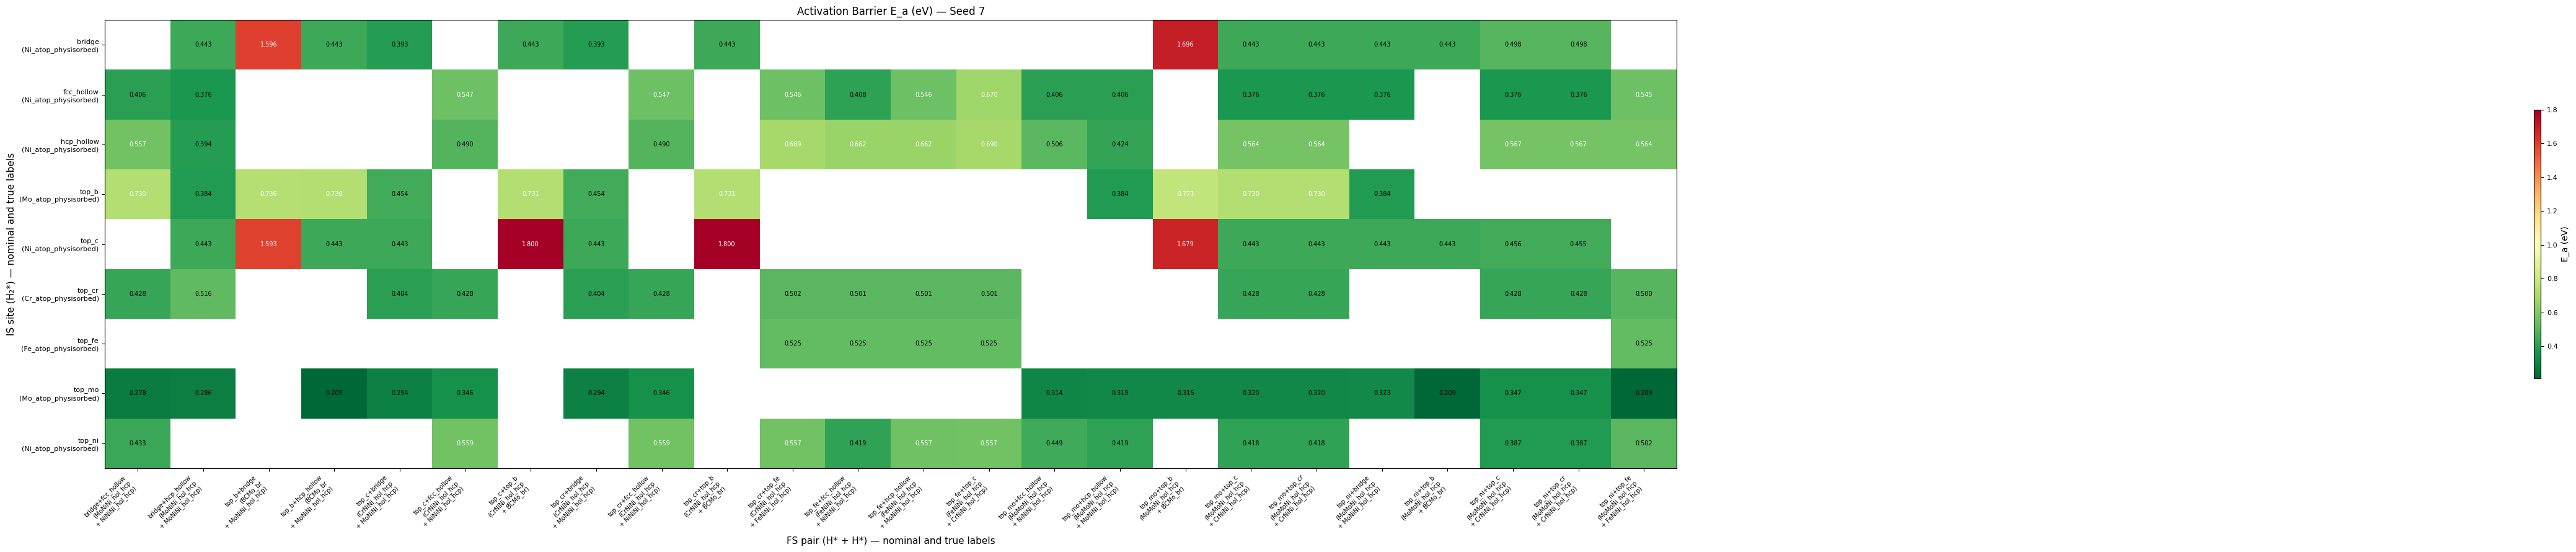

Saved: barrier_heatmap.png


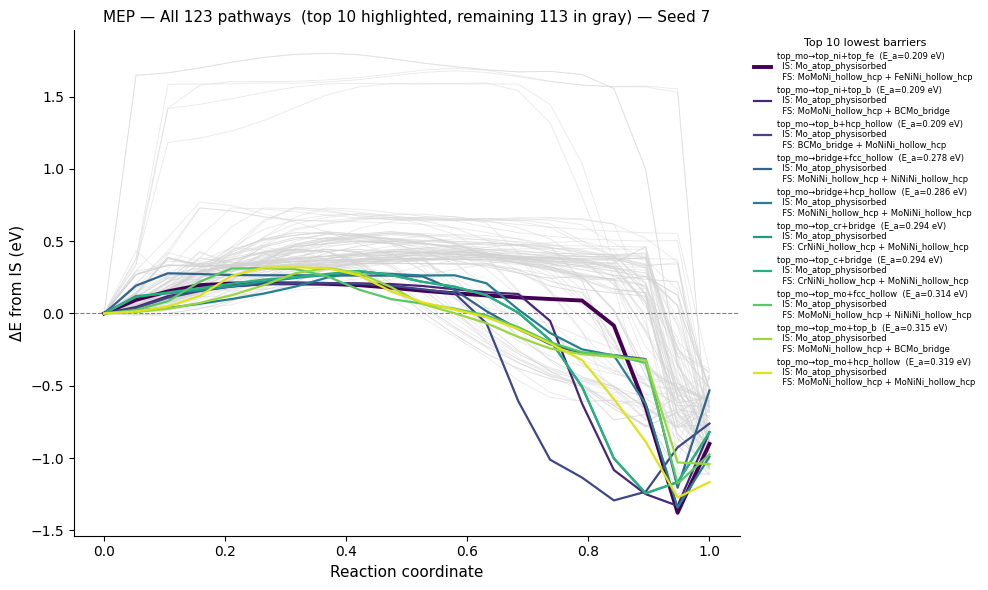

Saved: mep_overlay.png


In [19]:
# ─────────────────────────────────────────────────────────────
# Cell F — Plot barrier matrix and MEP overlay
# Uses true labels on axes; colorbar placed below the heatmap
# MEP plot highlights top 10 lowest barriers; rest shown in gray
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

if not results:
    print('No results to plot. Run Cell E first.')
else:
    df_plot = pd.DataFrame(results).dropna(subset=['E_a'])

    # ── Build display labels: nominal followed by true label ─
    is_display = {}
    for _, row in df_plot.iterrows():
        nom    = row['is_site']
        true_l = row.get('is_true_label', '') or '?'
        is_display[nom] = f'{nom}\n({true_l})'

    fs_display = {}
    for _, row in df_plot.iterrows():
        nom   = row['fs_pair']
        t1    = row.get('fs_true_label1', '') or '?'
        t2    = row.get('fs_true_label2', '') or '?'
        t1_s  = (t1.replace('_hollow_fcc', '_hol_fcc')
                   .replace('_hollow_hcp', '_hol_hcp')
                   .replace('_bridge', '_br')
                   .replace('_atop', '_at')
                   .replace('_physisorbed', '_phys'))
        t2_s  = (t2.replace('_hollow_fcc', '_hol_fcc')
                   .replace('_hollow_hcp', '_hol_hcp')
                   .replace('_bridge', '_br')
                   .replace('_atop', '_at')
                   .replace('_physisorbed', '_phys'))
        fs_display[nom] = f'{nom}\n({t1_s}\n + {t2_s})'

    # ══════════════════════════════════════════════════════════
    # Plot 1: Barrier matrix heatmap
    # ══════════════════════════════════════════════════════════
    is_sites_u = sorted(df_plot['is_site'].unique())
    fs_pairs_u = sorted(df_plot['fs_pair'].unique())

    matrix = np.full((len(is_sites_u), len(fs_pairs_u)), np.nan)
    for _, row in df_plot.iterrows():
        i = is_sites_u.index(row['is_site'])
        j = fs_pairs_u.index(row['fs_pair'])
        matrix[i, j] = row['E_a']

    fig, ax = plt.subplots(figsize=(max(10, len(fs_pairs_u)*2.0),
                                    max(6, len(is_sites_u)*1.0)))
    im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto',
                   vmin=np.nanmin(matrix), vmax=np.nanmax(matrix))

    ax.set_xticks(range(len(fs_pairs_u)))
    ax.set_xticklabels([fs_display[p] for p in fs_pairs_u],
                       rotation=45, ha='right', fontsize=7)
    ax.set_yticks(range(len(is_sites_u)))
    ax.set_yticklabels([is_display[s] for s in is_sites_u], fontsize=8)
    ax.set_xlabel('FS pair (H* + H*) — nominal and true labels', fontsize=11)
    ax.set_ylabel('IS site (H₂*) — nominal and true labels', fontsize=11)
    ax.set_title('Activation Barrier E_a (eV) — Seed 7', fontsize=12)

    for i in range(len(is_sites_u)):
        for j in range(len(fs_pairs_u)):
            if not np.isnan(matrix[i, j]):
                ax.text(j, i, f'{matrix[i, j]:.3f}',
                        ha='center', va='center', fontsize=7,
                        color='white' if matrix[i, j] > np.nanmean(matrix)
                                      else 'black')

    cbar = fig.colorbar(im, ax=ax, orientation='vertical',
                        pad=0.30, shrink=0.6, aspect=40)
    cbar.set_label('E_a (eV)', fontsize=10)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig('results/notebook06-Neb-dissociation/7/multi/barrier_heatmap.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: barrier_heatmap.png')

    # ══════════════════════════════════════════════════════════
    # Plot 2: MEP overlay — top 10 highlighted, rest in gray
    # ══════════════════════════════════════════════════════════
    N_HIGHLIGHT = 10
    df_top   = df_plot.nsmallest(N_HIGHLIGHT, 'E_a').reset_index(drop=True)
    df_other = df_plot[~df_plot['label'].isin(df_top['label'])]

    fig, ax = plt.subplots(figsize=(10, 6))

    # ── Background: all other pathways in light gray ─────────
    for _, row in df_other.iterrows():
        path_f = (f'results/notebook06-Neb-dissociation/7/multi/'
                  f'{row["label"]}/neb_path.dat')
        if not os.path.exists(path_f):
            continue
        data = np.loadtxt(path_f, comments='#')
        if data.ndim < 2:
            continue
        ax.plot(data[:, 0], data[:, 2],
                color='lightgray', linewidth=0.6, alpha=0.5, zorder=1)

    # ── Foreground: top N pathways in viridis ────────────────
    colors = cm.viridis(np.linspace(0, 0.95, len(df_top)))

    for (_, row), color in zip(df_top.iterrows(), colors):
        path_f = (f'results/notebook06-Neb-dissociation/7/multi/'
                  f'{row["label"]}/neb_path.dat')
        if not os.path.exists(path_f):
            continue
        data = np.loadtxt(path_f, comments='#')
        if data.ndim < 2:
            continue
        x, de = data[:, 0], data[:, 2]
        # Best pathway gets thicker line
        lw = 2.8 if row['label'] == df_top.iloc[0]['label'] else 1.6

        is_t  = row.get('is_true_label',  '') or '?'
        fs_t1 = row.get('fs_true_label1', '') or '?'
        fs_t2 = row.get('fs_true_label2', '') or '?'
        leg = (f'{row["is_site"]}→{row["fs_pair"]}  '
               f'(E_a={row["E_a"]:.3f} eV)\n'
               f'  IS: {is_t}\n'
               f'  FS: {fs_t1} + {fs_t2}')
        ax.plot(x, de, color=color, linewidth=lw, label=leg, zorder=3)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', zorder=2)
    ax.set_xlabel('Reaction coordinate', fontsize=11)
    ax.set_ylabel('ΔE from IS (eV)', fontsize=11)
    ax.set_title(f'MEP — All {len(df_plot)} pathways  '
                 f'(top {N_HIGHLIGHT} highlighted, '
                 f'remaining {len(df_other)} in gray) — Seed 7',
                 fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=6, frameon=False, ncol=1,
              bbox_to_anchor=(1.01, 1), loc='upper left',
              title=f'Top {N_HIGHLIGHT} lowest barriers',
              title_fontsize=8)
    plt.tight_layout()
    plt.savefig('results/notebook06-Neb-dissociation/7/multi/mep_overlay.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: mep_overlay.png')

In [16]:
print(data)

[[ 0.00000000e+00 -2.39810486e+03  0.00000000e+00]
 [ 5.26000000e-02 -2.39809027e+03  1.46000000e-02]
 [ 1.05300000e-01 -2.39805708e+03  4.78000000e-02]
 [ 1.57900000e-01 -2.39798235e+03  1.22500000e-01]
 [ 2.10500000e-01 -2.39784524e+03  2.59600000e-01]
 [ 2.63200000e-01 -2.39778749e+03  3.17400000e-01]
 [ 3.15800000e-01 -2.39778578e+03  3.19100000e-01]
 [ 3.68400000e-01 -2.39779092e+03  3.13900000e-01]
 [ 4.21100000e-01 -2.39784052e+03  2.64300000e-01]
 [ 4.73700000e-01 -2.39795069e+03  1.54200000e-01]
 [ 5.26300000e-01 -2.39802818e+03  7.67000000e-02]
 [ 5.78900000e-01 -2.39807713e+03  2.77000000e-02]
 [ 6.31600000e-01 -2.39813050e+03 -2.56000000e-02]
 [ 6.84200000e-01 -2.39821216e+03 -1.07300000e-01]
 [ 7.36800000e-01 -2.39831168e+03 -2.06800000e-01]
 [ 7.89500000e-01 -2.39842689e+03 -3.22000000e-01]
 [ 8.42100000e-01 -2.39869686e+03 -5.92000000e-01]
 [ 8.94700000e-01 -2.39899218e+03 -8.87300000e-01]
 [ 9.47400000e-01 -2.39937826e+03 -1.27340000e+00]
 [ 1.00000000e+00 -2.39927137e+

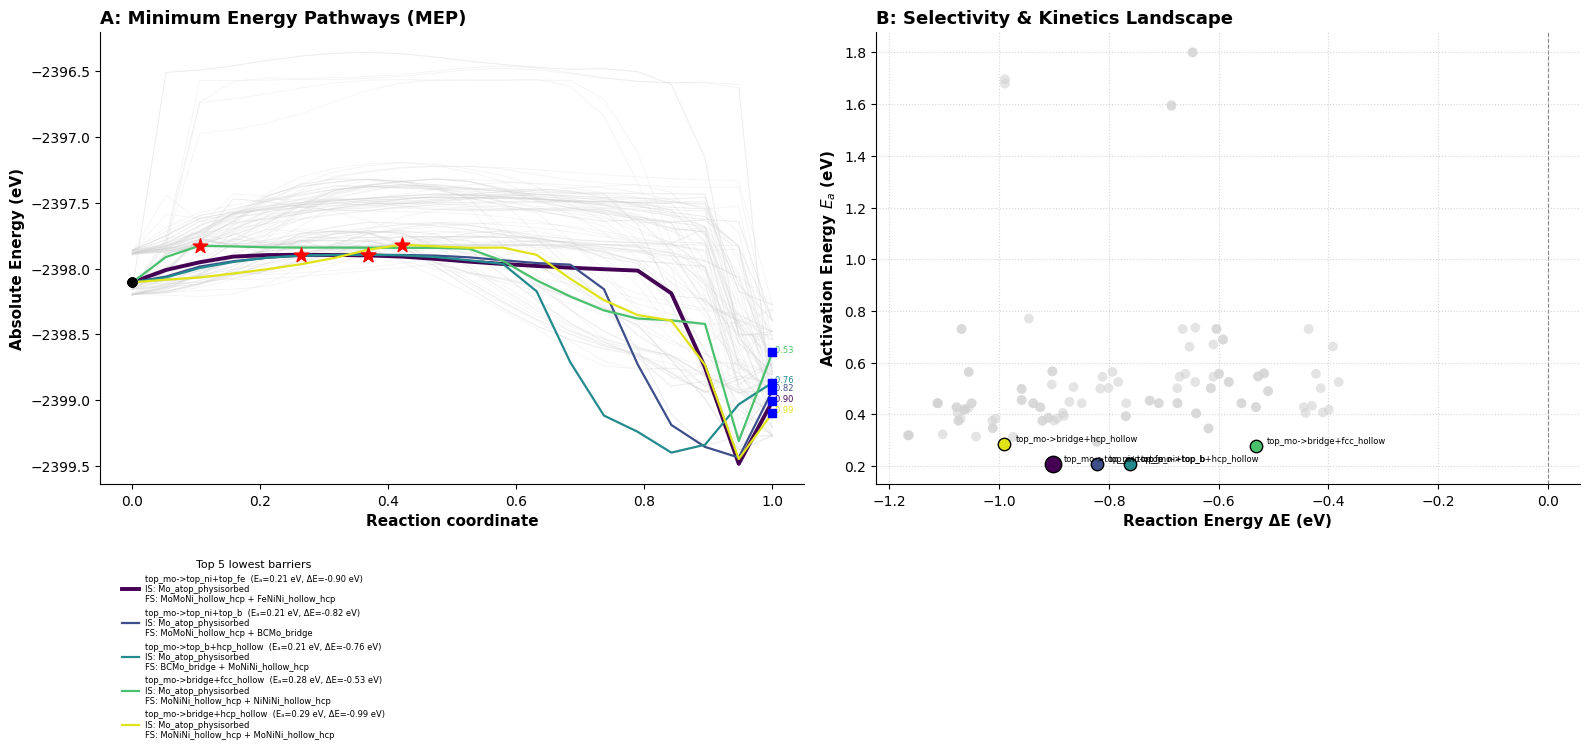

Saved 2-panel layout: results/notebook06-Neb-dissociation/7/multi/mep_selectivity_panel.png


In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ──────────────────────────────────────────────────────────────────────
# 1. Data Setup & Pre-calculations
# ──────────────────────────────────────────────────────────────────────
N_HIGHLIGHT = 5

# Calculate raw dE (FS - IS) for every pathway to use in Panel B
dE_list = []
for idx, row in df_plot.iterrows():
    path_f = f'results/notebook06-Neb-dissociation/{SEED}/multi/{row["label"]}/neb_path.dat'
    if os.path.exists(path_f):
        data = np.loadtxt(path_f, comments='#')
        if data.ndim >= 2:
            dE_list.append(data[-1, 1] - data[0, 1])
            continue
    dE_list.append(np.nan)

df_plot['dE_calculated'] = dE_list

# Split into top 10 lowest barriers and the rest
df_top = df_plot.nsmallest(N_HIGHLIGHT, 'E_a').reset_index(drop=True)
df_other = df_plot[~df_plot['label'].isin(df_top['label'])]

# ──────────────────────────────────────────────────────────────────────
# 2. Figure Layout Initialization
# ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
colors = cm.viridis(np.linspace(0, 0.95, len(df_top)))

# ======================================================================
# PANEL A: MEP Overlay (Absolute Energies)
# ======================================================================

# Background pathways (light gray)
for _, row in df_other.iterrows():
    path_f = f'results/notebook06-Neb-dissociation/{SEED}/multi/{row["label"]}/neb_path.dat'
    if not os.path.exists(path_f): continue
    data = np.loadtxt(path_f, comments='#')
    if data.ndim < 2: continue

    ax1.plot(data[:, 0], data[:, 1], color='lightgray', linewidth=0.6, alpha=0.25, zorder=1)

# Highlighted pathways (Top 10)
for (_, row), color in zip(df_top.iterrows(), colors):
    path_f = f'results/notebook06-Neb-dissociation/{SEED}/multi/{row["label"]}/neb_path.dat'
    if not os.path.exists(path_f): continue
    data = np.loadtxt(path_f, comments='#')
    if data.ndim < 2: continue

    x, E = data[:, 0], data[:, 1]
    ts_idx = np.argmax(E)
    lw = 2.8 if row['label'] == df_top.iloc[0]['label'] else 1.6

    is_t  = row.get('is_true_label', '?') or '?'
    fs_t1 = row.get('fs_true_label1', '?') or '?'
    fs_t2 = row.get('fs_true_label2', '?') or '?'
    dE = row['dE_calculated']

    leg = (f'{row["is_site"]}->{row["fs_pair"]}  '
           f'(Eₐ={row["E_a"]:.2f} eV, ΔE={dE:+.2f} eV)\n'
           f'IS: {is_t}\n'
           f'FS: {fs_t1} + {fs_t2}')

    # Plot lines & markers
    ax1.plot(x, E, color=color, linewidth=lw, label=leg, zorder=3)
    ax1.scatter(x[0], E[0], marker='o', s=40, color='black', zorder=5)
    ax1.scatter(x[ts_idx], E[ts_idx], marker='*', s=120, color='red', zorder=6)
    ax1.scatter(x[-1], E[-1], marker='s', s=40, color='blue', zorder=5)
    
    ax1.text(x[-1], E[-1], f'{dE:+.2f}', fontsize=6, color=color)

# Styling Panel A
ax1.set_xlabel('Reaction coordinate', fontsize=11, fontweight='bold')
ax1.set_ylabel('Absolute Energy (eV)', fontsize=11, fontweight='bold')
ax1.set_title('A: Minimum Energy Pathways (MEP)', fontsize=13, fontweight='bold', loc='left')
ax1.spines[['top', 'right']].set_visible(False)
ax1.ticklabel_format(useOffset=False, style='plain')

ax1.legend(fontsize=6, frameon=False, ncol=1,
          bbox_to_anchor=(0.02, -0.15),
          loc='upper left',
          title=f'Top {N_HIGHLIGHT} lowest barriers',
          title_fontsize=8)

# ======================================================================
# PANEL B: Selectivity Landscape (Ea vs ΔE)
# ======================================================================

# Plot all background pathways
ax2.scatter(df_other['dE_calculated'], df_other['E_a'],
            color='lightgray', alpha=0.6, s=50, edgecolors='none', 
            label='Other Pathways', zorder=2)

# Plot top pathways matching Panel A colors
for (_, row), color in zip(df_top.iterrows(), colors):
    # Marker is sized slightly larger if it represents the lowest overall barrier
    s_size = 140 if row['label'] == df_top.iloc[0]['label'] else 80
    
    ax2.scatter(row['dE_calculated'], row['E_a'],
                color=color, s=s_size, edgecolors='black', 
                linewidths=1.0, zorder=4)
    
    # Label specific points on the scatter plot for mapping clarity
    ax2.text(row['dE_calculated'] + 0.02, row['E_a'] + 0.01, 
             f'{row["is_site"]}->{row["fs_pair"]}', fontsize=6, color='black', zorder=5)

# Styling Panel B
ax2.set_xlabel('Reaction Energy ΔE (eV)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Activation Energy $E_a$ (eV)', fontsize=11, fontweight='bold')
ax2.set_title('B: Selectivity & Kinetics Landscape', fontsize=13, fontweight='bold', loc='left')
ax2.spines[['top', 'right']].set_visible(False)
ax2.grid(True, linestyle=':', alpha=0.5, zorder=1)

# Quadrant references to make the kinetic vs thermodynamic landscape intuitive
ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5, zorder=1)

# ──────────────────────────────────────────────────────────────────────
# 3. Save and Render
# ──────────────────────────────────────────────────────────────────────
plt.tight_layout()

# Extra room at bottom to prevent the multi-line Panel A legend from clipping
plt.subplots_adjust(bottom=0.3) 

output_path = f'results/notebook06-Neb-dissociation/{SEED}/multi/mep_selectivity_panel.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'Saved 2-panel layout: {output_path}')

In [15]:
print(data)

[[ 0.00000000e+00 -2.39810486e+03  0.00000000e+00]
 [ 5.26000000e-02 -2.39809027e+03  1.46000000e-02]
 [ 1.05300000e-01 -2.39805708e+03  4.78000000e-02]
 [ 1.57900000e-01 -2.39798235e+03  1.22500000e-01]
 [ 2.10500000e-01 -2.39784524e+03  2.59600000e-01]
 [ 2.63200000e-01 -2.39778749e+03  3.17400000e-01]
 [ 3.15800000e-01 -2.39778578e+03  3.19100000e-01]
 [ 3.68400000e-01 -2.39779092e+03  3.13900000e-01]
 [ 4.21100000e-01 -2.39784052e+03  2.64300000e-01]
 [ 4.73700000e-01 -2.39795069e+03  1.54200000e-01]
 [ 5.26300000e-01 -2.39802818e+03  7.67000000e-02]
 [ 5.78900000e-01 -2.39807713e+03  2.77000000e-02]
 [ 6.31600000e-01 -2.39813050e+03 -2.56000000e-02]
 [ 6.84200000e-01 -2.39821216e+03 -1.07300000e-01]
 [ 7.36800000e-01 -2.39831168e+03 -2.06800000e-01]
 [ 7.89500000e-01 -2.39842689e+03 -3.22000000e-01]
 [ 8.42100000e-01 -2.39869686e+03 -5.92000000e-01]
 [ 8.94700000e-01 -2.39899218e+03 -8.87300000e-01]
 [ 9.47400000e-01 -2.39937826e+03 -1.27340000e+00]
 [ 1.00000000e+00 -2.39927137e+